# 03 (Kaggle): Train Baseline

Runs on a **Kaggle GPU** notebook.

In [1]:
GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1_0vF1VFxGa1fIQSBkN3o1JJ1B-n-ikOg"
CACHE_FILENAME    = "icbhi_16k_8s.pt"
CACHE_DIR         = "/kaggle/working/icbhi_cache"
SAVE_DIR          = "/kaggle/working/checkpoints/baseline"

In [2]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/safina57/project-deep-learning.git"
REPO_DIR = Path("/kaggle/working/repo")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
print(f"project root: {REPO_DIR}")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "transformers", "librosa", "soundfile", "pyyaml", "gdown"],
    check=True,
)
print("deps installed")

Cloning into '/kaggle/working/repo'...


project root: /kaggle/working/repo
deps installed


In [3]:
import gdown

CACHE_PATH = Path(CACHE_DIR) / CACHE_FILENAME

if CACHE_PATH.exists():
    print(f"cache already present: {CACHE_PATH}")
else:
    Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
    gdown.download_folder(GDRIVE_FOLDER_URL, output=CACHE_DIR, quiet=False)
    print(f"downloaded folder to: {CACHE_DIR}")

assert CACHE_PATH.exists(), f"{CACHE_FILENAME} not found in {CACHE_DIR} after download."
print(f"cache: {CACHE_PATH}  ({CACHE_PATH.stat().st_size / 1e9:.2f} GB)")

# Verify cache has the val split (requires NB 02 re-run after 2026-05-02)
import torch
_probe = torch.load(CACHE_PATH, weights_only=False)
assert "x_val" in _probe, (
    "Cache is missing x_val — it was built with the old 2-split format. "
    "Re-run NB 02 to regenerate it with the train/val/test split."
)
print(f"cache format OK: train={_probe['x_train'].shape[0]}  val={_probe['x_val'].shape[0]}  test={_probe['x_test'].shape[0]}")
del _probe

Retrieving folder contents


Retrieving folder 1Rr9EVdkliFfKCiOTy-HM9mb0tmajLI-_ checkpoints
Retrieving folder 1PJf3TmxbO9mP9PJ930wtO2DCUfEbwpiS baseline
Processing file 1EbsOg1da52f_LbhbmRUE9qBAqtkhUPC5 icbhi_16k_8s.pt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1EbsOg1da52f_LbhbmRUE9qBAqtkhUPC5
From (redirected): https://drive.google.com/uc?id=1EbsOg1da52f_LbhbmRUE9qBAqtkhUPC5&confirm=t&uuid=bbf6309b-211b-4b0c-a2be-58b1930c75ad
To: /kaggle/working/icbhi_cache/icbhi_16k_8s.pt
100%|██████████| 3.53G/3.53G [00:19<00:00, 181MB/s] 
Download completed


downloaded folder to: /kaggle/working/icbhi_cache
cache: /kaggle/working/icbhi_cache/icbhi_16k_8s.pt  (3.53 GB)
cache format OK: train=3260  val=882  test=2756


In [4]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU found -- training will be very slow.")

GPU: Tesla T4
VRAM: 15.6 GB


In [5]:
import yaml
from src.training.train_loop import train

config = yaml.safe_load((REPO_DIR / "configs" / "baseline.yaml").read_text())
config["save_dir"] = SAVE_DIR

print("config:", config)
results = train(config, cache_path=CACHE_PATH, device=device)

config: {'lr': 1e-05, 'wd': 0.0001, 'rho': 0.05, 'batch_size': 8, 'epochs': 10, 'seed': 17, 'cache_path': 'data/cache/icbhi_16k_8s.pt', 'save_dir': '/kaggle/working/checkpoints/baseline'}


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

...

val:   0%|          | 0/28 [00:00<?, ?it/s]

[09/10] loss=0.1128  Se=56.88%  Sp=79.48%  Score=68.18%


epoch 10/10:   0%|          | 0/408 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

[10/10] loss=0.0768  Se=42.08%  Sp=88.93%  Score=65.51%


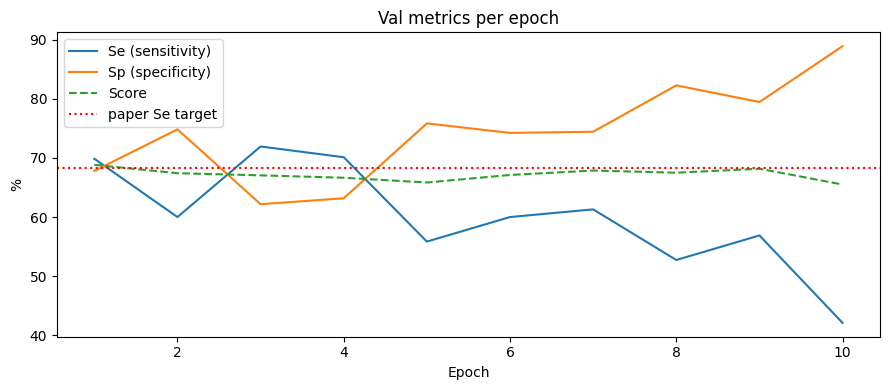

Best val  Se=71.95%  Sp=62.17%  Score=67.06%  (epoch 3)


In [6]:
import matplotlib.pyplot as plt

epochs = [m["epoch"] for m in results["history"]]
se     = [m["se"] * 100 for m in results["history"]]
sp     = [m["sp"] * 100 for m in results["history"]]
score  = [m["score"] * 100 for m in results["history"]]

plt.figure(figsize=(9, 4))
plt.plot(epochs, se,    label="Se (sensitivity)")
plt.plot(epochs, sp,    label="Sp (specificity)")
plt.plot(epochs, score, label="Score", linestyle="--")
plt.axhline(68.31, color="red", linestyle=":", label="paper Se target")
plt.xlabel("Epoch")
plt.ylabel("%")
plt.title("Val metrics per epoch")
plt.legend()
plt.tight_layout()
plt.show()

best = max(results["history"], key=lambda m: m["se"])
print(f"Best val  Se={best['se']*100:.2f}%  Sp={best['sp']*100:.2f}%  Score={best['score']*100:.2f}%  (epoch {best['epoch']})")

## Final test evaluation

Load the best-val-Se checkpoint and run once on the held-out test split.

In [7]:
from src.training.train_loop import evaluate_test
import numpy as np

print("Evaluating best checkpoint vs final epoch...\n")

m_best = evaluate_test(results["best_checkpoint"], CACHE_PATH, config, device)
m_last = evaluate_test(results["last_checkpoint"], CACHE_PATH, config, device)

print(f"{'Checkpoint':<30} {'Se':>7} {'Sp':>7} {'Score':>7}")
print("-" * 55)
print(f"{'best (val Score)  ' + m_best['checkpoint']:<30} {m_best['se']*100:>6.2f}% {m_best['sp']*100:>6.2f}% {m_best['score']*100:>6.2f}%")
print(f"{'last (final epoch) ' + m_last['checkpoint']:<30} {m_last['se']*100:>6.2f}% {m_last['sp']*100:>6.2f}% {m_last['score']*100:>6.2f}%")
print()
print("Reference paper:   Se=68.31%  Sp=67.89%  Score=68.10%")
print("AST baseline:      Se=69.87%  Sp=67.81%  Score=68.84%")
print("\nConfusion matrix — best checkpoint (rows=true, cols=pred):")
print(np.array(m_best["confusion_matrix"]))
print("\nConfusion matrix — last checkpoint (rows=true, cols=pred):")
print(np.array(m_last["confusion_matrix"]))
m_test = m_best


Evaluating best checkpoint vs final epoch...



Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Checkpoint                          Se      Sp   Score
-------------------------------------------------------
best (val Score)  best_score_epoch01.pt  79.27%  42.18%  60.72%
last (final epoch) last.pt      54.46%  82.84%  68.65%

Reference paper:   Se=68.31%  Sp=67.89%  Score=68.10%
AST baseline:      Se=69.87%  Sp=67.81%  Score=68.84%

Confusion matrix — best checkpoint (rows=true, cols=pred):
[[666 511 373  29]
 [180 420  23  26]
 [ 49  61 186  89]
 [ 15  30  44  54]]

Confusion matrix — last checkpoint (rows=true, cols=pred):
[[1308   86  175   10]
 [ 326  300   15    8]
 [ 157   24  171   33]
 [  53    9   43   38]]


In [8]:
import json, shutil
from pathlib import Path

save_dir = Path(SAVE_DIR)
save_dir.mkdir(parents=True, exist_ok=True)

results_path = save_dir / "results.json"
results_path.write_text(json.dumps({
    "experiment": config.get("model_type", "ast"),
    "config": config,
    "test_best": m_best,
    "test_last": m_last,
    "best_val": best,
    "history": results["history"],
}, indent=2))
print(f"results saved: {results_path}")

if "google.colab" in __import__("sys").modules:
    import shutil
    drive_dest = Path("/content/drive/MyDrive/icbhi_cache/checkpoints/baseline")
    shutil.copytree(str(save_dir), str(drive_dest), dirs_exist_ok=True)
    print(f"also copied to Drive: {drive_dest}")


results saved: /kaggle/working/checkpoints/baseline/results.json
